# Hospital Healthcare Analytics — Advanced Healthcare Analysis

This notebook performs advanced healthcare analytics to identify:

- High-utilization and high-cost patients
- Patient risk and utilization segments
- Cost concentration and Pareto patterns
- Readmission-like patient returns
- Diagnosis and procedure relationships
- Healthcare journey patterns
- Operational and financial insights
- Actionable healthcare recommendations

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [25]:
PROJECT_ROOT = Path.cwd().parents[1]
RAW_DATA = PROJECT_ROOT / "data" / "raw"

patients = pd.read_csv(RAW_DATA / "patients.csv")
encounters = pd.read_csv(RAW_DATA / "encounters.csv")
procedures = pd.read_csv(RAW_DATA / "procedures.csv")
payers = pd.read_csv(RAW_DATA / "payers.csv")
organizations = pd.read_csv(RAW_DATA / "organizations.csv")

encounters["START"] = pd.to_datetime(encounters["START"])
encounters["STOP"] = pd.to_datetime(encounters["STOP"])

procedures["START"] = pd.to_datetime(procedures["START"])
procedures["STOP"] = pd.to_datetime(procedures["STOP"])

encounters["CLAIM_COST"] = pd.to_numeric(
    encounters["TOTAL_CLAIM_COST"], errors="coerce"
)

encounters["PAYER_COVERAGE"] = pd.to_numeric(
    encounters["PAYER_COVERAGE"], errors="coerce"
)

encounters["OUT_OF_POCKET"] = (
    encounters["CLAIM_COST"] - encounters["PAYER_COVERAGE"]
).clip(lower=0)

encounters["LENGTH_OF_STAY_HOURS"] = (
    encounters["STOP"] - encounters["START"]
).dt.total_seconds() / 3600

print("Advanced analysis data loaded successfully.")

Advanced analysis data loaded successfully.


Patient Utilization Profile

In [26]:
patient_profile = (
    encounters
    .groupby("PATIENT")
    .agg(
        encounter_count=("Id", "count"),
        total_cost=("CLAIM_COST", "sum"),
        average_cost=("CLAIM_COST", "mean"),
        total_coverage=("PAYER_COVERAGE", "sum"),
        total_out_of_pocket=("OUT_OF_POCKET", "sum"),
        total_stay_hours=("LENGTH_OF_STAY_HOURS", "sum")
    )
    .reset_index()
)

patient_profile.head()

,PATIENT,encounter_count,total_cost,average_cost,total_coverage,total_out_of_pocket,total_stay_hours
0,002bc307-2fff-04ba-161b-98cce123e226,46,"13,742.67",298.75,"9,509.86","4,232.81",61.92
1,0034fe01-207f-275f-6b4b-821f7b0af044,75,"548,667.37","7,315.56","5,494.56","543,172.81",119.39
2,00abe029-00fa-a666-34f5-258a36978f6d,22,"48,334.27","2,197.01","6,384.67","41,949.60",6.79
3,010ff9c1-564b-6e32-09f4-29cb4224bba9,4,"26,367.50","6,591.88","19,475.04","6,892.46",1.71
4,01274098-150f-8211-6150-29f2a2da266c,1,0.00,0.00,0.00,0.00,24.00


Utilization Segmentation

In [27]:
patient_profile["UTILIZATION_SEGMENT"] = pd.cut(
    patient_profile["encounter_count"],
    bins=[0, 2, 5, 10, np.inf],
    labels=[
        "Low Utilization",
        "Moderate Utilization",
        "High Utilization",
        "Very High Utilization"
    ]
)

patient_profile["COST_SEGMENT"] = pd.qcut(
    patient_profile["total_cost"],
    q=4,
    labels=[
        "Low Cost",
        "Moderate Cost",
        "High Cost",
        "Very High Cost"
    ],
    duplicates="drop"
)

patient_profile.head()

,PATIENT,encounter_count,total_cost,average_cost,total_coverage,total_out_of_pocket,total_stay_hours,UTILIZATION_SEGMENT,COST_SEGMENT
0,002bc307-2fff-04ba-161b-98cce123e226,46,"13,742.67",298.75,"9,509.86","4,232.81",61.92,Very High Utilization,Moderate Cost
1,0034fe01-207f-275f-6b4b-821f7b0af044,75,"548,667.37","7,315.56","5,494.56","543,172.81",119.39,Very High Utilization,Very High Cost
2,00abe029-00fa-a666-34f5-258a36978f6d,22,"48,334.27","2,197.01","6,384.67","41,949.60",6.79,Very High Utilization,High Cost
3,010ff9c1-564b-6e32-09f4-29cb4224bba9,4,"26,367.50","6,591.88","19,475.04","6,892.46",1.71,Moderate Utilization,High Cost
4,01274098-150f-8211-6150-29f2a2da266c,1,0.00,0.00,0.00,0.00,24.00,Low Utilization,Low Cost


Utilization Segment Summary

In [28]:
segment_summary = (
    patient_profile
    .groupby("UTILIZATION_SEGMENT", observed=True)
    .agg(
        patients=("PATIENT", "count"),
        total_encounters=("encounter_count", "sum"),
        total_cost=("total_cost", "sum"),
        average_cost=("total_cost", "mean")
    )
    .reset_index()
)

segment_summary

,UTILIZATION_SEGMENT,patients,total_encounters,total_cost,average_cost
0,Low Utilization,170,220,"602,977.16","3,546.92"
1,Moderate Utilization,116,455,"1,605,718.28","13,842.40"
2,High Utilization,134,1048,"3,013,798.26","22,491.03"
3,Very High Utilization,554,26168,"96,291,881.82","173,812.06"


Utilization Segmentation Chart

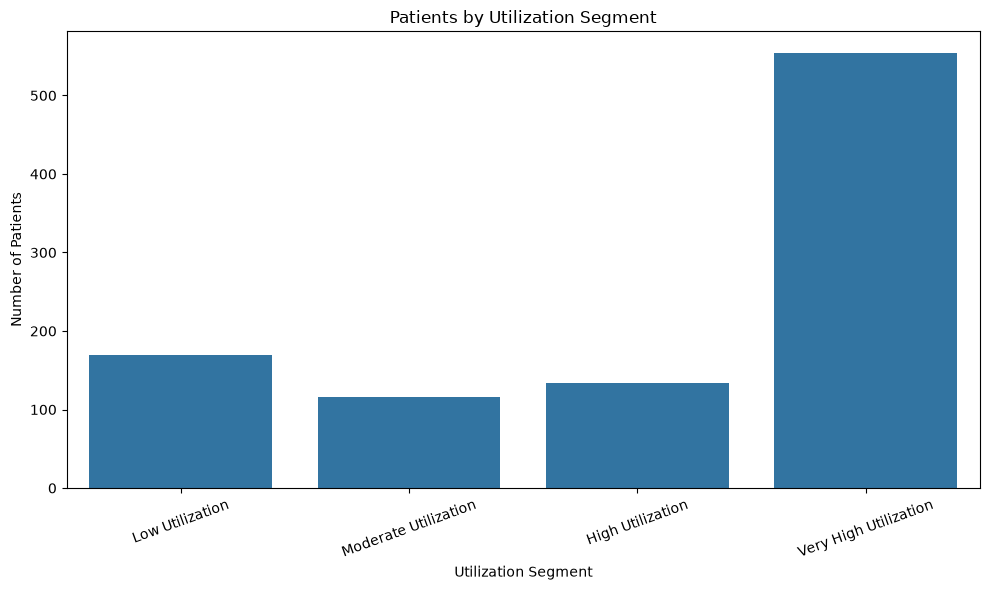

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x="UTILIZATION_SEGMENT",
    y="patients"
)

plt.title("Patients by Utilization Segment")
plt.xlabel("Utilization Segment")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Top 20 High-Cost Patients

In [30]:
top_cost_patients = (
    patient_profile
    .sort_values("total_cost", ascending=False)
    .head(20)
)

top_cost_patients

,PATIENT,encounter_count,total_cost,average_cost,total_coverage,total_out_of_pocket,total_stay_hours,UTILIZATION_SEGMENT,COST_SEGMENT
245,3f523789-55f3-bb31-2757-4803ca6a9c2a,447,"9,932,262.99","22,219.83",0.00,"9,932,262.99",240.75,Very High Utilization,Very High Cost
973,ff331e5c-ab16-e218-f39a-63e11de1ed75,291,"6,356,665.66","21,844.21","845,233.69","5,511,431.97",72.75,Very High Utilization,Very High Cost
647,a733bbc1-cbdf-992f-f1b7-bd230028fc4f,142,"3,014,121.02","21,226.20",0.00,"3,014,121.02",40.47,Very High Utilization,Very High Cost
174,2aa3ac2a-88c6-3253-547d-6d8ed69790a3,120,"2,699,823.10","22,498.53",0.00,"2,699,823.10",30.00,Very High Utilization,Very High Cost
85,1712d26d-822d-1e3a-2267-0a9dba31d7c8,1381,"2,437,415.31","1,764.96",0.00,"2,437,415.31","3,526.59",Very High Utilization,Very High Cost
900,eda6bc14-b236-e8c6-509a-b293e9cc688b,94,"2,090,033.12","22,234.39",0.00,"2,090,033.12",23.50,Very High Utilization,Very High Cost
221,37448778-ee2f-f420-1dc0-cb6b5e147025,53,"1,206,558.16","22,765.25",0.00,"1,206,558.16",13.25,Very High Utilization,Very High Cost
970,fea2a30d-f7c9-eeb0-9aad-5c711f55574f,106,"1,181,185.96","11,143.26",0.00,"1,181,185.96",49.51,Very High Utilization,Very High Cost
9,0226f105-2572-1c6f-15f0-1aa0438e40d0,180,"1,127,635.83","6,264.64",0.00,"1,127,635.83","1,820.00",Very High Utilization,Very High Cost
70,1375a6a6-5638-8af1-dc4f-2aa58220d36d,111,"1,030,983.91","9,288.14","54,044.35","976,939.56",27.75,Very High Utilization,Very High Cost


Cost Concentration / Pareto Analysis

In [31]:
cost_distribution = (
    patient_profile
    .sort_values("total_cost", ascending=False)
    .copy()
)

cost_distribution["cumulative_cost"] = (
    cost_distribution["total_cost"].cumsum()
)

total_patient_cost = cost_distribution["total_cost"].sum()

cost_distribution["cumulative_cost_pct"] = (
    cost_distribution["cumulative_cost"] /
    total_patient_cost * 100
)

cost_distribution["patient_pct"] = (
    np.arange(1, len(cost_distribution) + 1) /
    len(cost_distribution) * 100
)

cost_distribution.head(20)

,PATIENT,encounter_count,total_cost,average_cost,total_coverage,total_out_of_pocket,total_stay_hours,UTILIZATION_SEGMENT,COST_SEGMENT,cumulative_cost,cumulative_cost_pct,patient_pct
245,3f523789-55f3-bb31-2757-4803ca6a9c2a,447,"9,932,262.99","22,219.83",0.00,"9,932,262.99",240.75,Very High Utilization,Very High Cost,"9,932,262.99",9.78,0.10
973,ff331e5c-ab16-e218-f39a-63e11de1ed75,291,"6,356,665.66","21,844.21","845,233.69","5,511,431.97",72.75,Very High Utilization,Very High Cost,"16,288,928.65",16.05,0.21
647,a733bbc1-cbdf-992f-f1b7-bd230028fc4f,142,"3,014,121.02","21,226.20",0.00,"3,014,121.02",40.47,Very High Utilization,Very High Cost,"19,303,049.67",19.02,0.31
174,2aa3ac2a-88c6-3253-547d-6d8ed69790a3,120,"2,699,823.10","22,498.53",0.00,"2,699,823.10",30.00,Very High Utilization,Very High Cost,"22,002,872.77",21.67,0.41
85,1712d26d-822d-1e3a-2267-0a9dba31d7c8,1381,"2,437,415.31","1,764.96",0.00,"2,437,415.31","3,526.59",Very High Utilization,Very High Cost,"24,440,288.08",24.08,0.51
900,eda6bc14-b236-e8c6-509a-b293e9cc688b,94,"2,090,033.12","22,234.39",0.00,"2,090,033.12",23.50,Very High Utilization,Very High Cost,"26,530,321.20",26.13,0.62
221,37448778-ee2f-f420-1dc0-cb6b5e147025,53,"1,206,558.16","22,765.25",0.00,"1,206,558.16",13.25,Very High Utilization,Very High Cost,"27,736,879.36",27.32,0.72
970,fea2a30d-f7c9-eeb0-9aad-5c711f55574f,106,"1,181,185.96","11,143.26",0.00,"1,181,185.96",49.51,Very High Utilization,Very High Cost,"28,918,065.32",28.49,0.82
9,0226f105-2572-1c6f-15f0-1aa0438e40d0,180,"1,127,635.83","6,264.64",0.00,"1,127,635.83","1,820.00",Very High Utilization,Very High Cost,"30,045,701.15",29.60,0.92
70,1375a6a6-5638-8af1-dc4f-2aa58220d36d,111,"1,030,983.91","9,288.14","54,044.35","976,939.56",27.75,Very High Utilization,Very High Cost,"31,076,685.06",30.61,1.03


Pareto Visualization

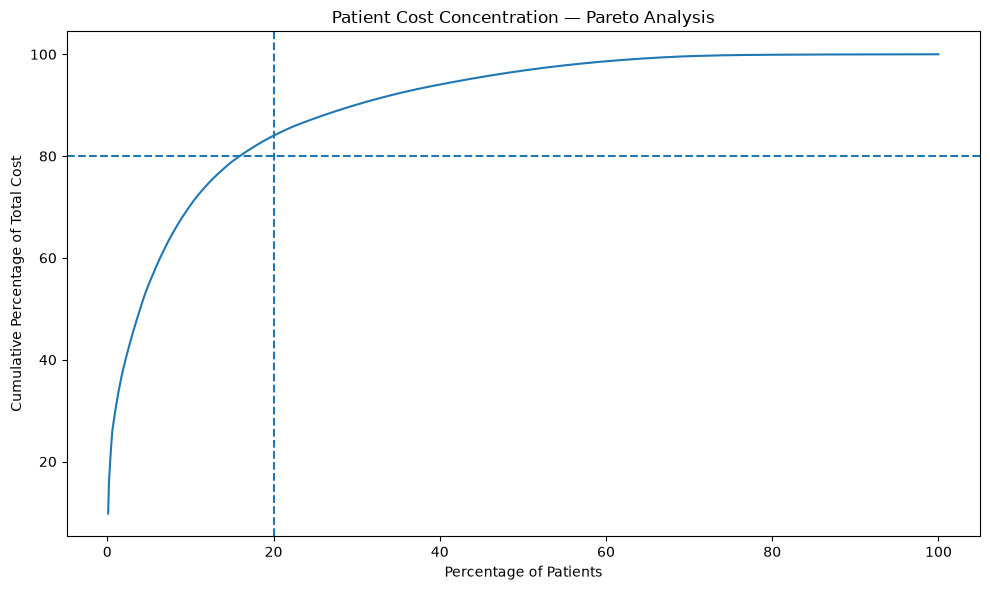

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(
    cost_distribution["patient_pct"],
    cost_distribution["cumulative_cost_pct"]
)

plt.axhline(80, linestyle="--")
plt.axvline(20, linestyle="--")

plt.title("Patient Cost Concentration — Pareto Analysis")
plt.xlabel("Percentage of Patients")
plt.ylabel("Cumulative Percentage of Total Cost")
plt.tight_layout()
plt.show()

Top 20% Cost Contribution

In [33]:
top_20_count = max(1, int(len(cost_distribution) * 0.20))

top_20_cost = (
    cost_distribution
    .head(top_20_count)["total_cost"]
    .sum()
)

top_20_percentage = (
    top_20_cost / total_patient_cost * 100
)

print(f"Top 20% of patients: {top_20_count:,}")
print(f"Total cost generated: ${top_20_cost:,.2f}")
print(f"Share of total patient cost: {top_20_percentage:.2f}%")

Top 20% of patients: 194
Total cost generated: $85,204,507.67
Share of total patient cost: 83.93%


Encounter Cost Outliers

In [34]:
cost_q1 = encounters["CLAIM_COST"].quantile(0.25)
cost_q3 = encounters["CLAIM_COST"].quantile(0.75)
cost_iqr = cost_q3 - cost_q1

cost_upper_limit = cost_q3 + (1.5 * cost_iqr)

cost_outliers = encounters[
    encounters["CLAIM_COST"] > cost_upper_limit
].copy()

print(f"Upper outlier threshold: ${cost_upper_limit:,.2f}")
print(f"Number of cost outliers: {len(cost_outliers):,}")

Upper outlier threshold: $3,317.46
Number of cost outliers: 5,316


Length-of-Stay Outliers

In [35]:
los_q1 = encounters["LENGTH_OF_STAY_HOURS"].quantile(0.25)
los_q3 = encounters["LENGTH_OF_STAY_HOURS"].quantile(0.75)
los_iqr = los_q3 - los_q1

los_upper_limit = los_q3 + (1.5 * los_iqr)

los_outliers = encounters[
    encounters["LENGTH_OF_STAY_HOURS"] > los_upper_limit
].copy()

print(f"Upper length-of-stay threshold: {los_upper_limit:.2f} hours")
print(f"Number of length-of-stay outliers: {len(los_outliers):,}")

Upper length-of-stay threshold: 1.79 hours
Number of length-of-stay outliers: 3,918


Patient Risk Profile

In [36]:
patient_profile["RISK_PROFILE"] = np.select(
    [
        (
            (patient_profile["encounter_count"] >= 10) &
            (patient_profile["total_cost"] >= patient_profile["total_cost"].quantile(0.75))
        ),
        (
            (patient_profile["encounter_count"] >= 5) |
            (patient_profile["total_cost"] >= patient_profile["total_cost"].quantile(0.75))
        )
    ],
    [
        "High Risk / High Utilization",
        "Elevated Utilization or Cost"
    ],
    default="Standard"
)

patient_profile["RISK_PROFILE"].value_counts()

RISK_PROFILE
Elevated Utilization or Cost    487
Standard                        252
High Risk / High Utilization    235
Name: count, dtype: int64

Risk Profile Visualization

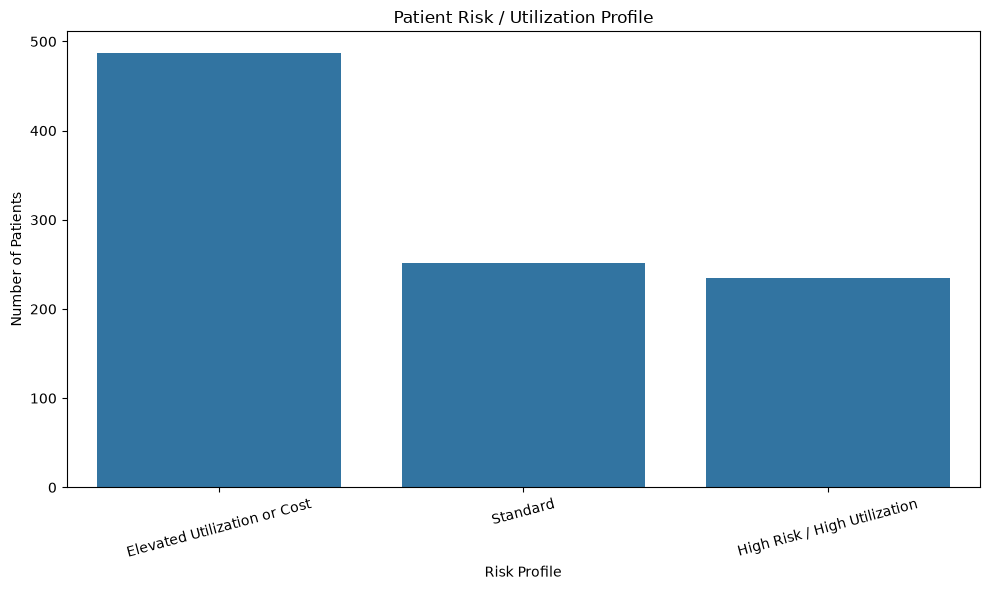

In [37]:
risk_summary = (
    patient_profile["RISK_PROFILE"]
    .value_counts()
    .reset_index()
)

risk_summary.columns = ["RISK_PROFILE", "PATIENT_COUNT"]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=risk_summary,
    x="RISK_PROFILE",
    y="PATIENT_COUNT"
)

plt.title("Patient Risk / Utilization Profile")
plt.xlabel("Risk Profile")
plt.ylabel("Number of Patients")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Patient Journey / Return Within 30 Days

In [38]:
journey = (
    encounters
    .sort_values(["PATIENT", "START"])
    .copy()
)

journey["PREVIOUS_STOP"] = (
    journey
    .groupby("PATIENT")["STOP"]
    .shift(1)
)

journey["DAYS_SINCE_PREVIOUS"] = (
    journey["START"] - journey["PREVIOUS_STOP"]
).dt.total_seconds() / 86400

journey["RETURN_WITHIN_30_DAYS"] = (
    journey["DAYS_SINCE_PREVIOUS"].between(0, 30)
)

journey.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,CLAIM_COST,OUT_OF_POCKET,LENGTH_OF_STAY_HOURS,PREVIOUS_STOP,DAYS_SINCE_PREVIOUS,RETURN_WITHIN_30_DAYS
1292,9365aa07-4ade-2cc0-f90c-a79085396a19,2011-12-22 19:30:33+00:00,2011-12-22 20:30:33+00:00,002bc307-2fff-04ba-161b-98cce123e226,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,emergency,50849002,Emergency Room Admission,146.18,146.18,84.94,"55,680,006.00",Drug overdose,146.18,61.24,1.00,NaT,NaN,False
1403,8fe2eb89-6036-de1e-7a4d-5fb1a663a5f3,2012-01-19 19:30:33+00:00,2012-01-20 19:30:33+00:00,002bc307-2fff-04ba-161b-98cce123e226,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,inpatient,56876005,Drug rehabilitation and detoxification,146.18,146.18,84.94,NaN,NaN,146.18,61.24,24.00,2011-12-22 20:30:33+00:00,27.96,True
8398,6b263c0d-9804-a271-397c-8e3db7ca0ad1,2014-06-19 19:30:33+00:00,2014-06-20 19:30:33+00:00,002bc307-2fff-04ba-161b-98cce123e226,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,inpatient,56876005,Drug rehabilitation and detoxification,146.18,146.18,84.94,NaN,NaN,146.18,61.24,24.00,2012-01-20 19:30:33+00:00,881.00,False
9343,10dab125-bdb0-12db-4c37-fa5e582670a1,2014-10-30 19:30:33+00:00,2014-10-30 19:45:33+00:00,002bc307-2fff-04ba-161b-98cce123e226,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185347001,Encounter for problem (procedure),85.55,85.55,36.44,NaN,NaN,85.55,49.11,0.25,2014-06-20 19:30:33+00:00,132.00,False
9579,03da09b8-1228-dd93-5e42-fd71f7e5183c,2014-11-29 19:30:33+00:00,2014-11-29 19:45:33+00:00,002bc307-2fff-04ba-161b-98cce123e226,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185347001,Encounter for problem (procedure),85.55,85.55,36.44,NaN,NaN,85.55,49.11,0.25,2014-10-30 19:45:33+00:00,29.99,True


30-Day Return Summary

In [39]:
return_summary = pd.DataFrame({
    "Total Encounters": [len(journey)],
    "Returns Within 30 Days": [
        journey["RETURN_WITHIN_30_DAYS"].sum()
    ],
    "Return Rate (%)": [
        journey["RETURN_WITHIN_30_DAYS"].mean() * 100
    ]
})

return_summary

,Total Encounters,Returns Within 30 Days,Return Rate (%)
0,27891,16786,60.18


Diagnosis Analysis

In [40]:
diagnosis_analysis = (
    encounters[
        encounters["REASONDESCRIPTION"].notna()
    ]
    .groupby("REASONDESCRIPTION")
    .agg(
        encounters=("Id", "count"),
        total_cost=("CLAIM_COST", "sum"),
        average_cost=("CLAIM_COST", "mean")
    )
    .sort_values("total_cost", ascending=False)
)

diagnosis_analysis.head(20)

,encounters,total_cost,average_cost
REASONDESCRIPTION,,,
Normal pregnancy,1341,"20,920,672.75","15,600.80"
COVID-19,26,"1,226,413.90","47,169.77"
Malignant neoplasm of breast (disorder),723,"1,158,205.08","1,601.94"
Chronic congestive heart failure (disorder),1738,"933,207.46",536.94
Acute bronchitis (disorder),352,"662,061.50","1,880.86"
Sepsis (disorder),4,"644,452.64","161,113.16"
Primary small cell malignant neoplasm of lung TNM stage 1 (disorder),53,"634,319.59","11,968.29"
Malignant tumor of colon,51,"537,411.07","10,537.47"
Hyperlipidemia,1565,"361,817.88",231.19


Diagnosis Analysis

In [41]:
procedure_analysis = (
    procedures
    .groupby("DESCRIPTION")
    .size()
    .reset_index(name="procedure_count")
    .sort_values("procedure_count", ascending=False)
)

procedure_analysis.head(20)

,DESCRIPTION,procedure_count
11,Assessment of health and social care needs (pr...,4596
69,Hospice care (regime/therapy),4098
46,Depression screening using Patient Health Ques...,3614
44,Depression screening (procedure),3614
12,Assessment of substance use (procedure),2906
124,Renal dialysis (procedure),2746
14,Assessment using Morse Fall Scale (procedure),2422
10,Assessment of anxiety (procedure),2288
95,Medication Reconciliation (procedure),2284
132,Screening for drug abuse (procedure),1484


Diagnosis Cost Efficiency

In [42]:
diagnosis_efficiency = (
    encounters[
        encounters["REASONDESCRIPTION"].notna()
    ]
    .groupby("REASONDESCRIPTION")
    .agg(
        encounters=("Id", "count"),
        total_cost=("CLAIM_COST", "sum"),
        average_cost=("CLAIM_COST", "mean")
    )
)

diagnosis_efficiency["cost_per_encounter"] = (
    diagnosis_efficiency["total_cost"] /
    diagnosis_efficiency["encounters"]
)

diagnosis_efficiency = diagnosis_efficiency.sort_values(
    "cost_per_encounter",
    ascending=False
)

diagnosis_efficiency.head(20)

,encounters,total_cost,average_cost,cost_per_encounter
REASONDESCRIPTION,,,,
Sepsis (disorder),4,"644,452.64","161,113.16","161,113.16"
COVID-19,26,"1,226,413.90","47,169.77","47,169.77"
Injury of anterior cruciate ligament,7,"116,506.25","16,643.75","16,643.75"
Injury of medial collateral ligament of knee,3,"49,895.69","16,631.90","16,631.90"
Rupture of patellar tendon,2,"33,166.17","16,583.08","16,583.08"
Normal pregnancy,1341,"20,920,672.75","15,600.80","15,600.80"
Acute Cholecystitis,2,"28,740.80","14,370.40","14,370.40"
Primary small cell malignant neoplasm of lung TNM stage 1 (disorder),53,"634,319.59","11,968.29","11,968.29"
Impacted molars,4,"46,394.94","11,598.74","11,598.74"


Encounter Type Operational Analysis

In [43]:
operational_analysis = (
    encounters
    .groupby("ENCOUNTERCLASS")
    .agg(
        encounters=("Id", "count"),
        average_length_hours=("LENGTH_OF_STAY_HOURS", "mean"),
        median_length_hours=("LENGTH_OF_STAY_HOURS", "median"),
        total_cost=("CLAIM_COST", "sum"),
        average_cost=("CLAIM_COST", "mean"),
        average_coverage=("PAYER_COVERAGE", "mean")
    )
    .sort_values("total_cost", ascending=False)
)

operational_analysis

,encounters,average_length_hours,median_length_hours,total_cost,average_cost,average_coverage
ENCOUNTERCLASS,,,,,,
ambulatory,12537,9.48,0.25,"36,283,440.84","2,894.11","1,029.23"
urgentcare,3666,0.25,0.25,"23,349,349.96","6,369.16",834.40
outpatient,6300,5.88,0.25,"14,094,967.12","2,237.30",599.64
emergency,2322,1.54,1.00,"10,750,051.53","4,629.65","1,398.29"
inpatient,1135,36.84,24.00,"8,809,134.34","7,761.35","3,250.01"
wellness,1931,0.25,0.25,"8,227,431.73","4,260.71","2,289.88"


Monthly Healthcare Activity

In [44]:
monthly_activity = (
    encounters
    .set_index("START")
    .resample("ME")
    .agg(
        encounters=("Id", "count"),
        total_cost=("CLAIM_COST", "sum"),
        average_cost=("CLAIM_COST", "mean")
    )
    .reset_index()
)

monthly_activity.head()

,START,encounters,total_cost,average_cost
0,2011-01-31 00:00:00+00:00,86,"259,121.74","3,013.04"
1,2011-02-28 00:00:00+00:00,86,"305,801.38","3,555.83"
2,2011-03-31 00:00:00+00:00,129,"327,225.51","2,536.63"
3,2011-04-30 00:00:00+00:00,113,"386,556.64","3,420.86"
4,2011-05-31 00:00:00+00:00,131,"417,517.16","3,187.15"


Monthly Cost Trend

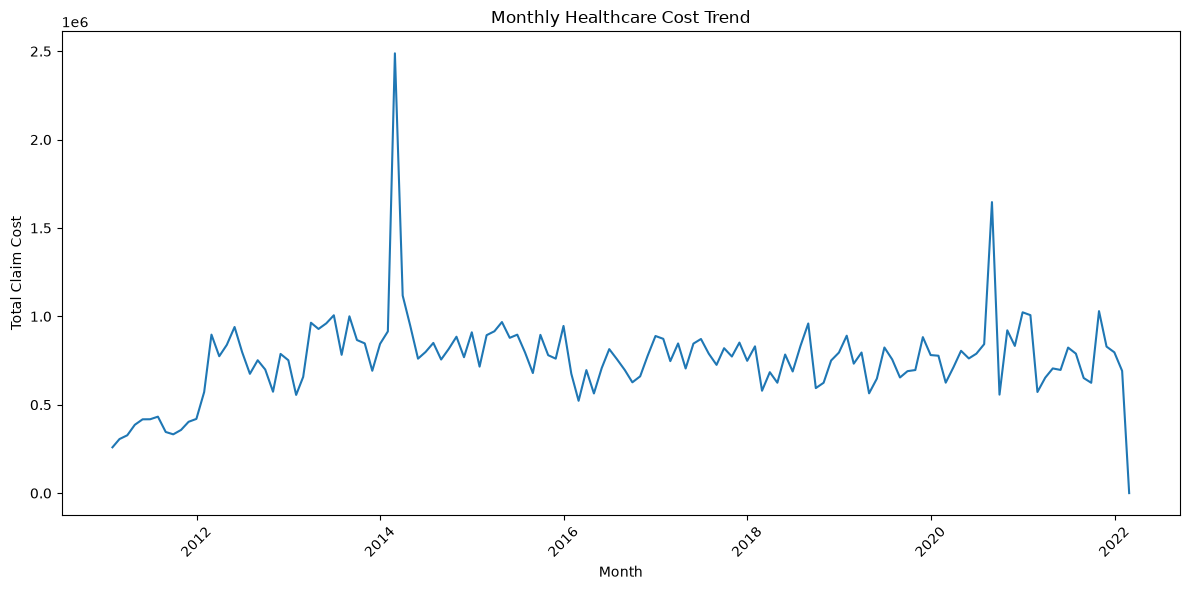

In [45]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_activity["START"],
    monthly_activity["total_cost"]
)

plt.title("Monthly Healthcare Cost Trend")
plt.xlabel("Month")
plt.ylabel("Total Claim Cost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Executive KPI Summary

In [46]:
executive_kpis = {
    "Total Patients": len(patients),
    "Total Encounters": len(encounters),
    "Total Procedures": len(procedures),
    "Total Claim Cost": encounters["CLAIM_COST"].sum(),
    "Total Payer Coverage": encounters["PAYER_COVERAGE"].sum(),
    "Total Out-of-Pocket Cost": encounters["OUT_OF_POCKET"].sum(),
    "Average Claim Cost": encounters["CLAIM_COST"].mean(),
    "Average Length of Stay (Hours)": encounters["LENGTH_OF_STAY_HOURS"].mean(),
    "30-Day Return Rate (%)": journey["RETURN_WITHIN_30_DAYS"].mean() * 100,
    "Top 20% Cost Contribution (%)": top_20_percentage
}

kpi_table = pd.DataFrame(
    list(executive_kpis.items()),
    columns=["KPI", "Value"]
)

kpi_table

,KPI,Value
0,Total Patients,974.00
1,Total Encounters,"27,891.00"
2,Total Procedures,"47,701.00"
3,Total Claim Cost,"101,514,375.52"
4,Total Payer Coverage,"31,097,506.99"
5,Total Out-of-Pocket Cost,"70,416,868.53"
6,Average Claim Cost,"3,639.68"
7,Average Length of Stay (Hours),7.27
8,30-Day Return Rate (%),60.18
9,Top 20% Cost Contribution (%),83.93


Export Advanced Results

In [47]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

patient_profile.to_csv(
    OUTPUT_DIR / "advanced_patient_profile.csv",
    index=False
)

top_cost_patients.to_csv(
    OUTPUT_DIR / "top_high_cost_patients.csv",
    index=False
)

diagnosis_analysis.head(50).to_csv(
    OUTPUT_DIR / "advanced_diagnosis_analysis.csv"
)

procedure_analysis.head(50).to_csv(
    OUTPUT_DIR / "advanced_procedure_analysis.csv",
    index=False
)

operational_analysis.to_csv(
    OUTPUT_DIR / "advanced_operational_analysis.csv"
)

monthly_activity.to_csv(
    OUTPUT_DIR / "monthly_healthcare_activity.csv",
    index=False
)

kpi_table.to_csv(
    OUTPUT_DIR / "advanced_healthcare_kpis.csv",
    index=False
)

print("Advanced healthcare analysis results exported successfully.")

Advanced healthcare analysis results exported successfully.


In [50]:
print("Merged shape:", diag_proc.shape)

print("\nMerged columns:")
for col in diag_proc.columns:
    print(f"- {col}")

Merged shape: (47701, 26)

Merged columns:
- Id
- START_x
- STOP_x
- PATIENT_x
- ORGANIZATION
- PAYER
- ENCOUNTERCLASS
- CODE_x
- DESCRIPTION_x
- BASE_ENCOUNTER_COST
- TOTAL_CLAIM_COST
- PAYER_COVERAGE
- REASONCODE_x
- REASONDESCRIPTION_x
- CLAIM_COST
- OUT_OF_POCKET
- LENGTH_OF_STAY_HOURS
- START_y
- STOP_y
- PATIENT_y
- ENCOUNTER
- CODE_y
- DESCRIPTION_y
- BASE_COST
- REASONCODE_y
- REASONDESCRIPTION_y


In [51]:
print("\nEncounter columns:")
print(encounters.columns.tolist())

print("\nProcedure columns:")
print(procedures.columns.tolist())


Encounter columns:
['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION', 'CLAIM_COST', 'OUT_OF_POCKET', 'LENGTH_OF_STAY_HOURS', 'DayOfWeek']

Procedure columns:
['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'BASE_COST', 'REASONCODE', 'REASONDESCRIPTION']


In [53]:
# Count distinct procedures by encounter diagnosis/reason
diag_proc = encounters.merge(
    procedures,
    left_on='Id',
    right_on='ENCOUNTER',
    how='inner'
)

sample_diag = (
    diag_proc
    .groupby('REASONDESCRIPTION_x')['CODE_y']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

print(
    "Diagnoses with most distinct procedures:\n",
    sample_diag
)


Diagnoses with most distinct procedures:
 REASONDESCRIPTION_x
Normal pregnancy                               47
Chronic congestive heart failure (disorder)    19
Hyperlipidemia                                 18
Malignant neoplasm of breast (disorder)        15
Viral sinusitis (disorder)                     15
Anemia (disorder)                              15
Acute bronchitis (disorder)                    14
Acute viral pharyngitis (disorder)             14
Alzheimer's disease (disorder)                 13
Sinusitis (disorder)                           12
Name: CODE_y, dtype: int64


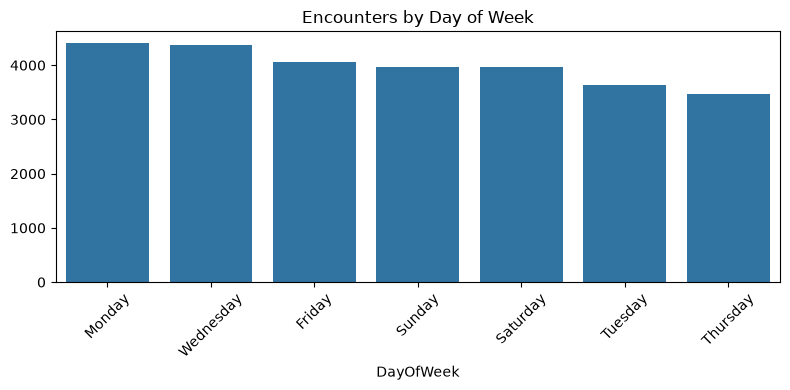

In [49]:
# Day-of-week encounter pattern
encounters['DayOfWeek'] = encounters['START'].dt.day_name()
dow_counts = encounters['DayOfWeek'].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(x=dow_counts.index, y=dow_counts.values)
plt.title("Encounters by Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PROJECT_ROOT  / "images" / "04_advanced_healthcare_analysis" / "dow_encounters.png")
plt.show()


Final Findings

## Advanced Healthcare Analysis — Key Findings

The advanced analysis evaluates patient utilization, cost concentration,
patient risk profiles, healthcare journeys, diagnosis patterns, procedure
activity, and operational performance.

### Areas of focus

1. **Patient utilization**
   - Patients were segmented according to encounter frequency.
   - High-utilization patients can be prioritized for deeper review.

2. **Cost concentration**
   - Pareto analysis identifies how healthcare costs are distributed across
     patients.
   - The highest-cost patient segment represents an important population for
     cost-management analysis.

3. **Patient risk**
   - Patients were categorized using utilization and cost indicators.
   - High-cost/high-utilization patients represent potential candidates for
     targeted care-management strategies.

4. **Patient journeys**
   - Encounters were examined for returns occurring within 30 days.
   - This provides a readmission-like utilization indicator.

5. **Diagnosis and procedures**
   - Diagnosis-level costs and procedure frequencies were analyzed to identify
     major healthcare activity and cost drivers.

6. **Operational performance**
   - Encounter types were compared using encounter volume, length of stay,
     claim cost, and payer coverage.

7. **Financial performance**
   - Claim costs, payer coverage, and estimated out-of-pocket costs were
     evaluated to understand the financial structure of healthcare utilization.

### Important note

This is an observational healthcare dataset. The analysis identifies
patterns and associations rather than proving clinical causation. The
30-day return metric is also a utilization indicator and should not
automatically be interpreted as a formal hospital readmission rate.